# Paper figures — Smallwood et al.
## Protecting astronomical sources during adaptive spatial filtering for radio frequency interference mitigation with the LAMBDA dipole array

Every figure and table in the paper is produced by this notebook.

Everything here belongs to the Orbcomm experiment of `pasguide.tex`
(§ *Imaging while mitigating Orbcomm satellite*, Fig. `fig:rfi-comparison`),
plus the controls that support it. All processing is offline, on visibilities
dumped by the GPU pipeline; all images are dirty images formed by DFT of the
visibilities using the antenna positions.

### Data

| | |
|---|---|
| Capture | `visibilities_20260611-1511_..._ALVEO0-3.hdf5`, 36 elements, 17.7 ms integrations |
| Gains | solved from the earlier Sun capture `...20260611-1349...` |
| Target channel | **4** — carries the Orbcomm downlink near 137.5 MHz |
| Clean channel | **0** — RFI-free, same time, same sky. This is the reference: successful mitigation should make channel 4 resemble channel 0 |
| Flagged antennas | 7 of 36 |
| Windows | four 120 s snapshots (≈6800 integrations each) at different satellite altitudes |

### The procedure, per 17.7 ms integration

Applied to the short-term covariance $R_k$ before integrating, as in
§ *Projecting and Correcting Visibilities*:


1. **Peel the known sky.** Subtract the scaled Haslam-model covariance,
   the scale capped per integration so the residual stays positive
   semi-definite (`psd_safe_subtract`).
2. **Whiten.**
3. **Null the interference subspace.** Project out the `rank` largest
   eigenmodes of the residual, after Gram–Schmidt removing the Sun's steering
   vector $b$ from the nulled subspace — the paper's
   $P_n = bb^{*} + \sum_{j\in\text{noise}} v_j v_j^{*}$
   (`fixed_rank_subspace_null_batch`).
4. **Shrink the Sun.** Scale the remaining response towards the Sun down to the
   noise level (`shrink_directional_eigenmodes_to_noise`), so the Sun does not
   dominate the colour scale of the Galactic-emission images.
5. **Restore.** Unwhiten and add back exactly the covariance removed at step 1.

The corrected covariances are then averaged over the 120 s window and imaged.
Steps 1 and 5 are the *extended-emission* protection; the Gram–Schmidt of
step 3 is the *point-source* protection. Rank is fixed here, not chosen by the
detection test of § *A simplified test for interference subspace detection*,
and the Leshem $L_k$ correction is **not** applied — both are deliberate, so
that each protection can be switched independently.


In [1]:
import os
from pathlib import Path

import matplotlib as mpl
import matplotlib.patheffects as patheffects
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sgp4.api import Satrec

from lambda_rfi_mitigation.constants import NARRIBRI
from lambda_rfi_mitigation.haslam_protection import (
    fixed_rank_subspace_null_batch, interpolate_covariances,
    psd_safe_subtract, shrink_directional_eigenmodes_to_noise,
)
from lambda_rfi_mitigation.low_rank_sky_experiment import (
    beam_weighted_haslam_components, beam_weighted_haslam_covariances,
)
from lambda_rfi_mitigation.protected_pipeline import (
    ProtectedRunConfig, dirty_image, galactic_plane_lm, prepare_observation,
    satellite_lm, steering_vectors, sun_lm_track,
)

target_name = 'visibilities_20260611-1511_172_179_ALVEO0_ALVEO1_ALVEO2_ALVEO3.hdf5'
gain_name = 'visibilities_20260611-1349_172_179_ALVEO0_ALVEO1_ALVEO2_ALVEO3.hdf5'

# The two captures are ~10 GiB each and are archived as a separate Zenodo data
# record (see README.md); they are not part of this repository. Point
# $LAMBDA_DATA_PATH at the directory holding them, or drop them (or symlinks to
# them) at the repository root.
DATA_DOI = 'https://doi.org/10.5281/zenodo.22255363'
search_roots = [
    Path(os.environ[name]) for name in ('LAMBDA_DATA_PATH',) if os.environ.get(name)
] + [Path('..'), Path('.')]
data_root = next(
    (root for root in search_roots if (root / target_name).exists()), None
)
if data_root is None:
    raise FileNotFoundError(
        'Could not locate the visibility captures\n'
        f'  {target_name}\n  {gain_name}\n'
        'Set $LAMBDA_DATA_PATH to the directory containing them, or place them '
        'at the repository root. They are archived at ' + DATA_DOI + '\n'
        'Searched: ' + ', '.join(str(root.resolve()) for root in search_roots)
    )
output_root = Path('.')          # this notebook writes its figures beside itself

# Fitted Haslam amplitude, carried over from the training run and NOT refitted
# here, so no free parameter is tuned against the results below. It is fitted on
# the satellite-free start of the capture (integrations [2000, 26000), 24 blocks)
# against the clean reference channels 0 and 1 -- the target channel is never
# RFI-free in time. Reproduce it with `python fit_haslam_scale.py`, which prints
#   Trained Haslam scale: 42.84 +/- 4.8   (MAD over the 24 blocks)
#   Median two-template fit residual fraction: 0.697
trained_haslam_scale = 42.84043253358354
fixed_rank = 7
falsification_rotation_degrees = 50.0
clean_channel = 0
snapshot_pixels = 256
snapshot_seconds = 120.0
# starts at index 30000 as the first part of the file has no satellite
config = ProtectedRunConfig(
    visibility_file=str(data_root / target_name),
    gain_file=str(data_root / gain_name),
    start_index=30000, target_channel=4, clean_channels=(0,),
    flag_antennas=(8, 9, 12, 14, 22, 33, 36),
    snapshot_pixels=snapshot_pixels, tw_margin=15.0,
)
observation = prepare_observation(config)
cadence_seconds = float(np.median(np.diff(observation.time.gps)))
snapshot_window = int(round(snapshot_seconds / cadence_seconds))

# ---- CONFIGURABLE WINDOWS ---------------------------------------------------
## relative to start_index
window_centres = [5000, 15000, 25000, 35000]
# ---------------------------------------------------------------------------
starts = np.clip(
    np.asarray(window_centres, dtype=int) - snapshot_window // 2,
    0, observation.ntime - snapshot_window,
)
stops = starts + snapshot_window
nwindow = len(starts)
if snapshot_window > observation.ntime:
    raise ValueError('snapshot window is longer than the loaded capture')

antenna_locations = observation.antenna_locations
target_frequency = observation.target_frequency
clean_frequency = float(observation.frequencies[clean_channel])
nant = antenna_locations.shape[0]

print('Snapshot window:', snapshot_window, 'integrations =',
      round(snapshot_window * cadence_seconds, 1), 's')
print('Window centres:', list(window_centres), '-> starts', list(map(int, starts)))
print(f'Clean Frequency: {clean_frequency / 1e6:.2f} MHz')
print('Trained Haslam scale:', trained_haslam_scale)
print('Fixed rank:', fixed_rank)
print('Antennas retained:', nant)

2026-09-03 19:28:23.979 | INFO     | lambda_rfi_mitigation.utils:read_hdf5_gains:48 - ['../visibilities_20260611-1349_172_179_ALVEO0_ALVEO1_ALVEO2_ALVEO3.hdf5']


2026-09-03 19:28:23.994 | INFO     | lambda_rfi_mitigation.utils:read_hdf5_time_freq:121 - <KeysViewHDF5 ['baseline_ids', 'vis_missing_nums', 'vis_seq_nums', 'visibilities']>


2026-09-03 19:28:23.995 | INFO     | lambda_rfi_mitigation.utils:read_hdf5_time_freq:122 - <KeysViewHDF5 ['max_channel', 'min_channel', 'mjd_start']>


2026-09-03 19:28:23.997 | INFO     | lambda_rfi_mitigation.utils:read_hdf5_time_freq:144 - Number of times: 65938


2026-09-03 19:28:23.997 | INFO     | lambda_rfi_mitigation.utils:read_hdf5_time_freq:145 - Number of channels: 8


...

2026-09-03 19:28:23.998 | INFO     | lambda_rfi_mitigation.utils:read_hdf5_time_freq:149 - Num Time Packets: 256.0


2026-09-03 19:28:23.998 | INFO     | lambda_rfi_mitigation.utils:read_hdf5_time_freq:150 - Time offset between visibilities: 0.01769472099840641 s / 17.694721221923828 ms


2026-09-03 19:28:25.891 | INFO     | lambda_rfi_mitigation.utils:read_hdf5_time_freq:175 - Applying index range: [30000, 65938) (35938 out of 65938 samples selected).


2026-09-03 19:28:25.895 | INFO     | lambda_rfi_mitigation.utils:make_telescope_model:291 - (36, 3)


Snapshot window: 6782 integrations = 120.0 s
Window centres: [5000, 15000, 25000, 35000] -> starts [1609, 11609, 21609, 29156]
Clean Frequency: 134.38 MHz
Trained Haslam scale: 42.84043253358354
Fixed rank: 7
Antennas retained: 29


## Shared toolkit

`null_and_restore` is the whole method in one function. Every call site below
turns each protection on or off by keyword, so a call reads as a statement of
which mechanisms are active:

| Argument | Off | On |
|---|---|---|
| `model=` | `None` — no Haslam peel, no add-back | model cube peeled at step 1 and restored at step 4 |
| `protect_sun=` | empty protected basis; the Sun may be nulled | Sun steering vector held out of the nulled subspace |
| `shrink_sun=` | Sun left at full strength | Sun response shrunk to noise, per integration |

It returns the integrated covariance plus the diagnostics used later:
`filtered` (per-integration covariances after nulling, before add-back),
`removed_mean` (the Haslam covariance actually removed — the *template* every
correlation below is measured against), `cap` (the PSD cap applied per
integration; a cap below 1 means the model had to be throttled), and the mean
Sun response before/after shrinking.

**Arithmetic is preserved bit-for-bit from the original notebook.** Two details
are deliberate rather than stylistic, and are kept explicit so numbers are
reproducible:

- `reduce='mean'` averages with `np.mean` (pairwise summation), `reduce='running'`
  accumulates sequentially; over ~6800 terms the two differ in the last bits.
  The original used both, in the places marked.
- The unrotated model comes from `beam_weighted_haslam_covariances`, rotated
  models from `rotated_haslam_covariances`. At 0° these agree to roundoff but
  are not the same code path, and the original used both.

In [2]:
import hashlib
from collections import OrderedDict

# ============================ geometry and models ============================

def rotate_lm(lm, degrees):
    """Rotate row-vector l,m coordinates counter-clockwise about zenith."""
    angle = np.deg2rad(float(degrees))
    cosine, sine = np.cos(angle), np.sin(angle)
    return np.asarray(lm) @ np.array([[cosine, sine], [-sine, cosine]])


def rotated_haslam_covariances(times, antenna_locations, frequency, degrees):
    """Beam-weight Haslam, then rotate its apparent structure by any angle."""
    output = []
    for time_value in times:
        lm, weights, _ = beam_weighted_haslam_components(time_value, frequency)
        vectors = steering_vectors(
            rotate_lm(lm, degrees), antenna_locations, frequency
        )
        covariance = np.einsum(
            's,si,sj->ij', weights, vectors, np.conj(vectors), optimize=True
        )
        output.append(0.5 * (covariance + covariance.conj().T))
    return np.asarray(output)


def model_node_times(times):
    """The three times at which the Haslam model is evaluated: start, mid, end.

    The model is then linearly interpolated across the window, so the sky model
    tracks the rotation of the sky during the 120 s integration.
    """
    return np.array([0, len(times) // 2, len(times) - 1])


def physical_haslam_model(times, scale=None):
    """Scaled Haslam model covariance for every integration (no rotation)."""
    scale = trained_haslam_scale if scale is None else scale
    return scale * interpolate_covariances(
        haslam_nodes(times), len(times)
    )


def rotated_haslam_model(times, degrees, scale=None):
    """As `physical_haslam_model`, with the sky model rotated by `degrees`.

    Used as the falsified control: a model that cannot be correct.
    """
    scale = trained_haslam_scale if scale is None else scale
    return scale * interpolate_covariances(
        haslam_nodes(times, degrees), len(times)
    )


# ============================== data loading =================================

# Caches. The same window is loaded and modelled by several cells below; a
# read costs ~10 s and a cube ~46 MB, so a handful are kept. Nothing writes
# into a loaded cube (psd_safe_subtract and fixed_rank_subspace_null_batch
# both copy), so sharing one array between call sites is safe.
_window_cache = OrderedDict()
_haslam_node_cache = {}
WINDOW_CACHE_SIZE = 6


def load_window(selection, channel, obs=None):
    """Load one channel and flag integrations that are unusable.

    An integration is valid when every visibility is finite and every
    autocorrelation is positive (needed for whitening).
    """
    obs = observation if obs is None else obs
    key = (id(obs), selection.start, selection.stop, channel)
    if key in _window_cache:
        _window_cache.move_to_end(key)
        return _window_cache[key]
    cube = obs.load_channel(selection, channel)
    diagonal = np.real(np.diagonal(cube, axis1=-2, axis2=-1))
    valid = (
        np.all(np.isfinite(cube), axis=(1, 2))
        & np.all(diagonal > 0.0, axis=1)
    )
    _window_cache[key] = (cube, valid)
    while len(_window_cache) > WINDOW_CACHE_SIZE:
        _window_cache.popitem(last=False)
    return cube, valid


def haslam_nodes(times, degrees=None):
    """Beam-weighted Haslam covariances at the window's three node times.

    `degrees=None` is the unrotated model. Cached on the node times, so a
    window modelled in several cells is evaluated once.
    """
    node_times = times[model_node_times(times)]
    key = (tuple(np.round(node_times.gps, 6)), degrees)
    if key not in _haslam_node_cache:
        if degrees is None:
            nodes, _ = beam_weighted_haslam_covariances(
                node_times, antenna_locations, target_frequency,
            )
        else:
            nodes = rotated_haslam_covariances(
                node_times, antenna_locations, target_frequency, degrees,
            )
        _haslam_node_cache[key] = nodes
    return _haslam_node_cache[key]


def sun_steering(times, frequency, obs=None):
    """Sun steering vector at each integration time."""
    obs = observation if obs is None else obs
    return steering_vectors(
        sun_lm_track(times), obs.antenna_locations, frequency,
    )


# ========================= the procedure (core) ==============================

def _null_and_restore_uncached(
    cube, directions, base_valid, rank, *,
    model=None, protect_sun=True, shrink_sun=True, reduce='mean',
    mode='null', obs=None,
):
    """Run *the procedure* over one window and return the integrated covariance.

    Parameters name the protections, so a call site reads as a statement of
    which mechanisms are on:

    model        : Haslam model cube to peel before nulling and add back after.
                   `None` runs on the raw visibilities with no extended-emission
                   protection and no add-back.
    protect_sun  : remove the Sun's steering vector from the nulled subspace
                   (the point-source protection). `False` gives an empty
                   protected basis, so the Sun may be nulled.
    shrink_sun   : shrink the Sun's response to the noise level after nulling,
                   per integration.
    reduce       : 'mean' -> np.mean over the batch; 'running' -> sequential
                   accumulation. Kept explicit because the two differ in the
                   last bits and the original used both.
    mode         : 'null' removes the `rank` leading modes outright;
                   'shrink' scales them down to the noise floor instead.

    Returns a dict with the integrated covariance and the per-window
    diagnostics the original collected.
    """
    obs = observation if obs is None else obs
    if reduce not in ('mean', 'running'):
        raise ValueError("reduce must be 'mean' or 'running'")

    if model is None:
        # No Haslam peel: null the raw visibilities directly.
        residual, removed, cap = cube, None, None
        valid = base_valid
    else:
        residual, removed, cap, subtraction_valid = psd_safe_subtract(cube, model)
        valid = base_valid & subtraction_valid

    valid_directions = directions[valid]
    if protect_sun:
        basis = valid_directions[:, :, None]
    else:
        basis = np.empty(
            (int(np.count_nonzero(valid)), obs.antenna_locations.shape[0], 0),
            dtype=complex,
        )
    filtered, _ = fixed_rank_subspace_null_batch(
        residual[valid], basis, rank, mode=mode
    )

    valid_removed = None if removed is None else removed[valid]
    n = filtered.shape[0]
    sun_before = np.empty(n)
    sun_after = np.empty(n)
    sun_noise = np.empty(n)

    def term(k):
        """The contribution of integration k to the window average."""
        if shrink_sun:
            peeled, info = shrink_directional_eigenmodes_to_noise(
                filtered[k], valid_directions[k:k + 1],
                obs.snapshots_per_integration,
            )
            sun_before[k] = info['response_before']
            sun_after[k] = info['response_after']
            sun_noise[k] = info['noise_level']
        else:
            peeled = filtered[k]
            sun_before[k] = sun_after[k] = sun_noise[k] = np.nan
        if valid_removed is None:
            return peeled
        return peeled + valid_removed[k]

    if reduce == 'mean':
        batch = np.empty_like(filtered)
        for k in range(n):
            batch[k] = term(k)
        covariance = np.mean(batch, axis=0)
    else:
        total = np.zeros_like(filtered[0])
        for k in range(n):
            total += term(k)
        covariance = total / n

    # Only reductions are returned: the per-integration cubes are ~45 MB each
    # and every consumer takes their mean, so the means are what get cached.
    return {
        'covariance': covariance,
        'valid': valid,
        'filtered_mean': np.mean(filtered, axis=0),
        'removed_mean': None if valid_removed is None else np.mean(valid_removed, axis=0),
        'cap': None if cap is None else cap[valid],
        'sun_response_before': np.mean(sun_before),
        'sun_response_after': np.mean(sun_after),
        'sun_response_to_noise': np.mean(sun_after / sun_noise),
    }


# ============================ result caching =================================
# `null_and_restore` costs ~6 s a call and the notebook makes ~130 of them, so
# results are memoised to disk. The key is a digest of every input, meaning a
# changed window, rank, model or flag misses the cache automatically; only the
# figure code downstream is free to change without invalidating anything.

CACHE_DIR = output_root / 'cache'
CACHE_DIR.mkdir(exist_ok=True)
USE_DISK_CACHE = True     # set False to force recomputation


def _digest(*parts):
    """Stable digest of arrays and scalars."""
    hasher = hashlib.blake2b(digest_size=16)
    for part in parts:
        if part is None:
            hasher.update(b'\x00none')
        elif isinstance(part, np.ndarray):
            array = np.ascontiguousarray(part)
            hasher.update(str(array.dtype).encode())
            hasher.update(str(array.shape).encode())
            hasher.update(array.view(np.uint8).reshape(-1)[:].tobytes())
        else:
            hasher.update(repr(part).encode())
    return hasher.hexdigest()


def null_and_restore(
    cube, directions, base_valid, rank, *,
    model=None, protect_sun=True, shrink_sun=True, reduce='mean',
    mode='null', obs=None,
):
    """Disk-memoised `_null_and_restore_uncached`; same arguments and result."""
    if not USE_DISK_CACHE:
        return _null_and_restore_uncached(
            cube, directions, base_valid, rank, model=model,
            protect_sun=protect_sun, shrink_sun=shrink_sun, reduce=reduce,
            mode=mode, obs=obs,
        )
    key = _digest(
        cube, directions, base_valid, rank, model,
        protect_sun, shrink_sun, reduce, mode,
    )
    path = CACHE_DIR / f'null_and_restore-{key}.npz'
    if path.exists():
        with np.load(path, allow_pickle=True) as stored:
            return {
                name: (None if stored[name].dtype == object
                       and stored[name].item() is None else stored[name])
                for name in stored.files
            }
    result = _null_and_restore_uncached(
        cube, directions, base_valid, rank, model=model,
        protect_sun=protect_sun, shrink_sun=shrink_sun, reduce=reduce,
        mode=mode, obs=obs,
    )
    np.savez_compressed(path, **{
        name: (np.array(None, dtype=object) if value is None else value)
        for name, value in result.items()
    })
    return result


# ================================ imaging ====================================

def image_of(covariance, frequency=None, obs=None):
    """Dirty image of one covariance on the standard snapshot grid."""
    obs = observation if obs is None else obs
    frequency = obs.target_frequency if frequency is None else frequency
    return dirty_image(
        covariance, frequency, obs.antenna_locations, snapshot_pixels,
    )


_axis_grid = np.linspace(-1, 1, snapshot_pixels)
_L_grid, _M_grid = np.meshgrid(_axis_grid, _axis_grid, indexing='ij')
_disk_corr = np.hypot(_L_grid, _M_grid) <= 1.0


def image_corr(first, second):
    """Pearson correlation of two images over the visible hemisphere."""
    mask = _disk_corr & np.isfinite(first) & np.isfinite(second)
    return float(np.corrcoef(first[mask], second[mask])[0, 1])


_image_corr = image_corr  # original name, kept so downstream code is unchanged


def peak_in_disk(image):
    """Brightest pixel inside the horizon; the suppression statistic."""
    return np.nanmax(image[_disk_corr])


def sym_log_norm(values, percentile=99.8):
    limit = float(np.nanpercentile(np.abs(values), percentile))
    return mpl.colors.SymLogNorm(
        linthresh=max(limit * 1e-3, np.finfo(float).eps),
        vmin=-limit, vmax=limit, base=10,
    )

In [3]:
# ============================ plotting helpers ===============================
# Overlays (Sun, satellite, Galactic plane) recomputed from the window times.

snapshot_times = observation.time[(starts + stops - 1) // 2]
_satellite = Satrec.twoline2rv(*config.tle)
_offset = config.ephemeris_time_offset_s
snapshot_sun_lm = sun_lm_track(snapshot_times)
snapshot_satellite_lm = np.array([
    satellite_lm(t, _satellite, _offset)[:2] for t in snapshot_times
])
snapshot_galactic_plane_lm = np.array([
    galactic_plane_lm(t) for t in snapshot_times
])
# n^2 = 1 - l^2 - m^2; altitude = arcsin(n).
snapshot_altitude_deg = np.degrees(np.arcsin(np.sqrt(np.clip(
    1.0 - np.sum(snapshot_satellite_lm ** 2, axis=1), 0.0, 1.0
))))
_track_idx = np.unique(np.r_[
    np.arange(0, observation.ntime, 50), observation.ntime - 1
])
satellite_track_lm = np.array([
    satellite_lm(observation.time[int(k)], _satellite, _offset)[:2]
    for k in _track_idx
])

# Sanity check retained from the original: the general rotation routine must
# reproduce the dedicated quarter-turn path exactly.
_qt_reference, _ = beam_weighted_haslam_covariances(
    observation.time[[starts[0]]], antenna_locations, target_frequency,
    apparent_rotation_quarter_turns=1,
)
_qt_general = rotated_haslam_covariances(
    observation.time[[starts[0]]], antenna_locations, target_frequency, 90.0,
)
assert np.allclose(_qt_general, _qt_reference, rtol=1e-12)
del _qt_general, _qt_reference

# Paper style. Sizes are the final (smaller) values used by these figures;
# fonttype 42 keeps text as editable TrueType in the PDF/PS output.
mpl.rcParams.update({
    'font.family': 'serif',
    'font.size': 7.0, 'axes.titlesize': 7.0, 'axes.labelsize': 7.0,
    'xtick.labelsize': 6.0, 'ytick.labelsize': 6.0,
    'legend.fontsize': 6.0, 'figure.titlesize': 8.0,
    'lines.linewidth': 0.9, 'axes.linewidth': 0.7,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})
cmap = mpl.colormaps['RdBu_r'].copy()
cmap.set_bad('0.90')

SATELLITE_COLOUR = '#E69F00'
SUN_COLOUR = 'black'
PLANE_COLOUR = '#F0E442'
ROTATED_COLOUR = '#CC79A7'

legend_handles = (
    mpl.lines.Line2D([], [], color=SATELLITE_COLOUR, lw=0.8),
    mpl.lines.Line2D([], [], color='black', marker='x', ls='none', ms=5.5,
                     markeredgewidth=1.4),
    mpl.lines.Line2D([], [], color=SUN_COLOUR, marker='o',
                     markerfacecolor='none', ls='none', ms=4.2,
                     markeredgewidth=0.8),
    mpl.lines.Line2D([], [], color=PLANE_COLOUR, ls='--', lw=0.8,
                     path_effects=[]),
)
LEGEND_LABELS = ('Satellite track', 'Satellite', 'Sun', 'Galactic plane')


def draw_lm_panel(axis, image, norm, *, window=None, overlays=True,
                  plane_only=False, plane_lm=None, marker_scale=1.0):
    """Show one dirty image in (l, m) with the standard overlays.

    The image is transposed because `dirty_image` returns it indexed [l, m]
    while imshow treats the first axis as rows; x is inverted so east is left.
    """
    shown = axis.imshow(
        image.T, extent=[-1, 1, -1, 1], origin='lower', cmap=cmap, norm=norm,
    )
    if overlays:
        axis.plot(
            satellite_track_lm[:, 0], satellite_track_lm[:, 1],
            color=SATELLITE_COLOUR, lw=0.7, zorder=2,
        )
        if window is not None:
            # zorder + white halo: the marker must read on top of the
            # satellite track and the image, not blend into either.
            axis.scatter(
                *snapshot_satellite_lm[window], marker='x', color='black',
                s=40 * marker_scale, linewidths=1.4, zorder=6,
                path_effects=[patheffects.withStroke(
                    linewidth=2.6, foreground='white'
                )],
            )
            axis.scatter(
                *snapshot_sun_lm[window], marker='o', facecolors='none',
                edgecolors=SUN_COLOUR, s=16 * marker_scale, linewidths=0.8,
                zorder=5, path_effects=[patheffects.withStroke(
                    linewidth=1.4, foreground='white'
                )],
            )
    if overlays or plane_only:
        # plane_only draws the Galactic plane with no satellite or Sun markers.
        plane = snapshot_galactic_plane_lm[window] if plane_lm is None else plane_lm
        axis.plot(plane[:, 0], plane[:, 1], color='black', lw=1.0, alpha=0.75)
        axis.plot(plane[:, 0], plane[:, 1], color=PLANE_COLOUR, lw=0.55, ls='--')
    axis.set(
        xlim=(1, -1), ylim=(-1, 1), aspect='equal',
        xticks=[-1, 0, 1], yticks=[-1, 0, 1],
    )
    return shown


def add_signed_colourbar(figure, shown, axes, norm, label):
    """Horizontal colourbar ticked at -limit, 0, +limit in scientific notation."""
    colourbar = figure.colorbar(
        shown, ax=axes, orientation='horizontal',
        fraction=0.025, pad=0.025, aspect=13,
    )
    limit = float(norm.vmax)
    colourbar.set_ticks([-limit, 0.0, limit])
    colourbar.ax.xaxis.set_major_formatter(
        mpl.ticker.FuncFormatter(lambda value, _: f'{value:.1e}')
    )
    colourbar.ax.minorticks_off()
    colourbar.ax.tick_params(labelsize=5.5, pad=1)
    colourbar.set_label(label, fontsize=5.5, labelpad=1)
    return colourbar


# Five image products per window, in storage order.
IMAGE_RAW, IMAGE_UNPROTECTED, IMAGE_PROTECTED, IMAGE_MODEL, IMAGE_CLEAN = range(5)

# Display order of the five products: model, clean, raw, unprotected, protected.
COMPARISON_ORDER = (
    IMAGE_MODEL, IMAGE_CLEAN, IMAGE_RAW, IMAGE_UNPROTECTED, IMAGE_PROTECTED,
)
COMPARISON_TITLES = (
    '(a) Haslam model', '(b) Clean ch.', '(c) Raw data',
    '(d) Unprotected', '(e) Protected',
)
COMPARISON_LABELS = ('Haslam', 'Clean ch.', 'Raw', 'Unprotected', 'Protected')


def save_figure(figure, path, **kwargs):
    """Save as vector PDF and PNG, whatever suffix `path` carries."""
    kwargs.setdefault('bbox_inches', 'tight')
    kwargs.setdefault('pad_inches', 0.05)
    path = Path(path)
    for suffix in ('.pdf', '.png'):
        figure.savefig(path.with_suffix(suffix), **kwargs)
    return path.with_suffix('.pdf')


def five_column_comparison(image_set, norms, path, dpi=None):
    """The model/clean/raw/unprotected/protected grid, one row per window.

    `image_set` and `norms` stay in the storage order (raw, unprotected,
    protected, model, clean); `COMPARISON_ORDER` maps them onto the columns.
    The unprotected column carries only the Galactic plane, no Sun or
    satellite markers.
    """
    figure, axes = plt.subplots(
        nwindow, 5, figsize=(7.1, 1.45 * nwindow), sharex=True, sharey=True,
        constrained_layout=True, squeeze=False,
    )
    figure.set_constrained_layout_pads(
        w_pad=0.01, h_pad=0.01, wspace=0.015, hspace=0.02,
    )
    shown = [None] * 5
    for row in range(nwindow):
        for column, source in enumerate(COMPARISON_ORDER):
            unprotected_column = source == IMAGE_UNPROTECTED
            shown[column] = draw_lm_panel(
                axes[row, column], image_set[source, row], norms[source],
                window=row, overlays=not unprotected_column,
                plane_only=unprotected_column,
            )
        axes[row, 0].set_ylabel(f'$m$\nalt. {snapshot_altitude_deg[row]:.0f}°')
    for axis, title in zip(axes[0], COMPARISON_TITLES):
        axis.set_title(title)
    for axis in axes[-1]:
        axis.set_xlabel('$l$ (east left)')
    for column, label in enumerate(COMPARISON_LABELS):
        add_signed_colourbar(
            figure, shown[column], axes[:, column],
            norms[COMPARISON_ORDER[column]], label,
        )
    figure.legend(
        legend_handles, LEGEND_LABELS, loc='upper center',
        bbox_to_anchor=(0.5, -0.045), ncol=4, frameon=False,
    )
    save_kwargs = {'bbox_inches': 'tight', 'pad_inches': 0.05}
    if dpi is not None:
        save_kwargs['dpi'] = dpi
    # Both formats every run, so the PNG never lags the PDF.
    for suffix in ('.pdf', '.png'):
        figure.savefig(path.with_suffix(suffix), **save_kwargs)
    return figure, axes

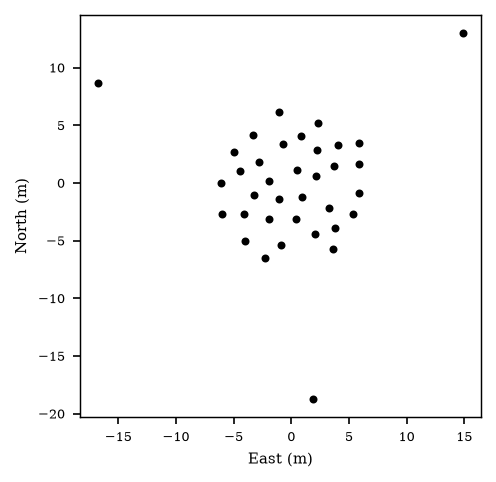

Saved: lambda36-array-layout.pdf


In [4]:
# --- array layout, in the paper style (vector PDF + PNG) ---
# Geometry comes from the packaged LAMBDA36 telescope model, drawn here as
# vector output matching the other figures' fonts.
from lambda_rfi_mitigation import utils

layout_array = utils.make_telescope_model(np.arange(1, 37), telescope='LAMBDA36')
layout_figure, layout_axis = plt.subplots(figsize=(3.31, 3.31))
layout_axis.scatter(layout_array.east, layout_array.north, c='k', s=8)
layout_axis.set(xlabel='East (m)', ylabel='North (m)', aspect='equal')
layout_figure.tight_layout()
layout_path = save_figure(layout_figure, output_root / 'lambda36-array-layout.pdf')
plt.show()
print('Saved:', layout_path)


## Four-window processing at fixed rank 7 (computation only)


In [5]:
# Four-window processing at the fixed rank, no figure: later cells need the
# covariances and the five image products, which the removed figure cells used
# to build.
#   0 raw, 1 unprotected, 2 protected restored, 3 Haslam add-back, 4 clean ch.
IMAGE_RAW, IMAGE_UNPROTECTED, IMAGE_PROTECTED, IMAGE_MODEL, IMAGE_CLEAN = range(5)

raw_covariance = np.empty((nwindow, nant, nant), dtype=np.complex128)
unprotected_fixed_covariance = np.empty_like(raw_covariance)
protected_restored_covariance = np.empty_like(raw_covariance)
removed_haslam_covariance = np.empty_like(raw_covariance)
clean_sun_shrunk_covariance = np.empty_like(raw_covariance)
sun_response_to_noise = np.full(nwindow, np.nan)

for window, (start, stop) in enumerate(zip(starts, stops)):
    selection = slice(int(start), int(stop))
    times = observation.time[selection]
    target, target_valid = load_window(selection, config.target_channel)
    directions = sun_steering(times, target_frequency)

    # --- clean channel control: Sun shrink only, no nulling, no Haslam.
    clean_cube, clean_valid = load_window(selection, clean_channel)
    clean_directions = sun_steering(times[clean_valid], clean_frequency)
    clean_sun_shrunk_covariance[window], _ = shrink_directional_eigenmodes_to_noise(
        np.mean(clean_cube[clean_valid], axis=0), clean_directions,
        observation.snapshots_per_integration * int(np.count_nonzero(clean_valid)),
    )

    # --- protected: Haslam peel + Sun protected + Sun shrink + add-back.
    protected = null_and_restore(
        target, directions, target_valid, fixed_rank,
        model=physical_haslam_model(times),
        protect_sun=True, shrink_sun=True, reduce='mean',
    )
    # --- unprotected: no Haslam, no Sun protection, no Sun shrink.
    unprotected = null_and_restore(
        target, directions, target_valid, fixed_rank,
        model=None, protect_sun=False, shrink_sun=False, reduce='mean',
    )

    protected_restored_covariance[window] = protected['covariance']
    unprotected_fixed_covariance[window] = unprotected['covariance']
    removed_haslam_covariance[window] = protected['removed_mean']
    raw_covariance[window] = np.mean(target[target_valid], axis=0)
    sun_response_to_noise[window] = protected['sun_response_to_noise']
    print('Processed window', window + 1)

images = np.empty((5, nwindow, snapshot_pixels, snapshot_pixels))
for window in range(nwindow):
    for column, (covariance, frequency) in enumerate((
        (raw_covariance[window], target_frequency),
        (unprotected_fixed_covariance[window], target_frequency),
        (protected_restored_covariance[window], target_frequency),
        (removed_haslam_covariance[window], target_frequency),
        (clean_sun_shrunk_covariance[window], clean_frequency),
    )):
        images[column, window] = image_of(covariance, frequency)
print('Sun response/noise:', sun_response_to_noise)


2026-09-03 19:28:27.662 | INFO     | lambda_rfi_mitigation.protected_pipeline:_selection_to_hdf5:107 - returning 6782 time steps...


2026-09-03 19:28:41.070 | INFO     | lambda_rfi_mitigation.protected_pipeline:_selection_to_hdf5:107 - returning 6782 time steps...


2026-09-03 19:28:53.354 | INFO     | lambda_rfi_mitigation.protected_pipeline:_selection_to_hdf5:107 - returning 6782 time steps...


Processed window 1


2026-09-03 19:29:04.806 | INFO     | lambda_rfi_mitigation.protected_pipeline:_selection_to_hdf5:107 - returning 6782 time steps...


...

2026-09-03 19:29:40.940 | INFO     | lambda_rfi_mitigation.protected_pipeline:_selection_to_hdf5:107 - returning 6782 time steps...


Processed window 3


2026-09-03 19:29:52.442 | INFO     | lambda_rfi_mitigation.protected_pipeline:_selection_to_hdf5:107 - returning 6782 time steps...


Processed window 4


Sun response/noise: [1.00086799 1.00074937 1.00003114 1.00004862]


## Satellite-free control

The same 120 s Sun-shrink-only processing on an earlier stretch of the same
capture, asserted to have no satellite above the horizon, on both the target
and the clean channel.

With no RFI to remove, the two channels should already agree. This fixes the
baseline correlation the mitigated results are trying to reach and shows that
the target–clean comparison is not measuring some fixed inter-channel offset.

In [6]:
from dataclasses import replace

satellite_free_start = 1000  # Absolute HDF5 integration index.
satellite_free_stop = satellite_free_start + snapshot_window
full_observation = prepare_observation(replace(config, start_index=0), verbose=False)
satellite_free_selection = slice(satellite_free_start, satellite_free_stop)
satellite_free_times = full_observation.time[satellite_free_selection]
satellite_check_indices = np.linspace(0, snapshot_window - 1, 25, dtype=int)
satellite_altitudes = np.array([
    satellite_lm(satellite_free_times[i], _satellite, _offset)[2]
    for i in satellite_check_indices
])
assert satellite_free_times.size == snapshot_window
assert np.max(satellite_altitudes) < 0.0   # no satellite up in this stretch

sun_only_images = []
sun_only_response_to_noise = []
for channel in (config.target_channel, clean_channel):
    frequency = float(full_observation.frequencies[channel])
    cube, valid = load_window(satellite_free_selection, channel, obs=full_observation)
    directions = sun_steering(
        satellite_free_times[valid], frequency, obs=full_observation,
    )
    peeled, information = shrink_directional_eigenmodes_to_noise(
        np.mean(cube[valid], axis=0), directions,
        full_observation.snapshots_per_integration * np.count_nonzero(valid),
    )
    sun_only_images.append(
        image_of(peeled, frequency, obs=full_observation)
    )
    sun_only_response_to_noise.append(
        information['response_after'] / information['noise_level']
    )

satellite_free_correlation = image_corr(*sun_only_images)
satellite_free_table = pd.DataFrame({
    'start_index': [satellite_free_start],
    'stop_index_exclusive': [satellite_free_stop],
    'duration_s': [snapshot_window * cadence_seconds],
    'satellite_altitude_min_deg': [np.min(satellite_altitudes)],
    'satellite_altitude_max_deg': [np.max(satellite_altitudes)],
    'target_clean_correlation': [satellite_free_correlation],
    'target_sun_response_to_noise': [sun_only_response_to_noise[0]],
    'clean_sun_response_to_noise': [sun_only_response_to_noise[1]],
})
satellite_free_path = output_root / (
    'haslam_fixed7_satellite_free_sun_only_correlation_120s.csv'
)
satellite_free_table.to_csv(satellite_free_path, index=False)
print(
    f'Satellite-free raw indices {satellite_free_start}:{satellite_free_stop} '
    f'({snapshot_window * cadence_seconds:.1f} s); '
    f'Sun-only target–clean correlation = {satellite_free_correlation:.3f}'
)
satellite_free_table

2026-09-03 19:30:07.682 | INFO     | lambda_rfi_mitigation.utils:read_hdf5_gains:48 - ['../visibilities_20260611-1349_172_179_ALVEO0_ALVEO1_ALVEO2_ALVEO3.hdf5']


2026-09-03 19:30:09.287 | INFO     | lambda_rfi_mitigation.protected_pipeline:_selection_to_hdf5:107 - returning 6782 time steps...


2026-09-03 19:30:21.538 | INFO     | lambda_rfi_mitigation.protected_pipeline:_selection_to_hdf5:107 - returning 6782 time steps...


Satellite-free raw indices 1000:7782 (120.0 s); Sun-only target–clean correlation = 0.796


,start_index,stop_index_exclusive,duration_s,satellite_altitude_min_deg,satellite_altitude_max_deg,target_clean_correlation,target_sun_response_to_noise,clean_sun_response_to_noise
0,1000,7782,120.005535,-13.506569,-8.713199,0.796323,1.064079,1.044085


## Rank sweep on window 2 — paper Fig. 4

Nulled rank 0–10 through four branches, plus the peak-suppression statistic.
Rank 0 nulls nothing, so it is the untouched reference; the curve shows what
each additional nulled eigenmode buys and where over-nulling begins.

**One caveat about the labels.** The branch called "unprotected" here keeps
`protect_sun=True` and `shrink_sun=True` — it is *Haslam*-unprotected only.
That is not the same "unprotected" as in the four-window figure, where all
three protections are off. This is the original definition, kept for continuity;
the two Sun operations are separated cleanly in the isolation experiment below.

`reduce='running'` here, `reduce='mean'` in the four-window block: see the
toolkit note. The rank-7 point is asserted equal to the four-window fixed-7
result.

In [7]:
rank_window = 1
rank_sweep = np.arange(11)
rank_sweep_correlations = np.empty((rank_sweep.size, 3))
unprotected_rank_correlations = np.empty(rank_sweep.size)
unprotected_template_correlations = np.empty(rank_sweep.size)
rotated_rank_correlations = np.empty(rank_sweep.size)
rank_sweep_dirty_images = np.empty(
    (rank_sweep.size, snapshot_pixels, snapshot_pixels)
)
unprotected_rank_images = np.empty_like(rank_sweep_dirty_images)

rank_selection = slice(int(starts[rank_window]), int(stops[rank_window]))
rank_times = observation.time[rank_selection]
rank_clean_image = images[IMAGE_CLEAN, rank_window]
rank_target, rank_target_valid = load_window(rank_selection, config.target_channel)
rank_directions = sun_steering(rank_times, target_frequency)

rank_model = physical_haslam_model(rank_times)
rotated_rank_model = rotated_haslam_model(
    rank_times, falsification_rotation_degrees
)

# Templates: the mean Haslam covariance actually removed, imaged.
_probe = null_and_restore(
    rank_target, rank_directions, rank_target_valid, 0,
    model=rank_model, protect_sun=True, shrink_sun=False, reduce='mean',
)
rank_template_image = image_of(_probe['removed_mean'])
_rot_probe = null_and_restore(
    rank_target, rank_directions, rank_target_valid, 0,
    model=rotated_rank_model, protect_sun=True, shrink_sun=False, reduce='mean',
)
rotated_rank_template_image = image_of(_rot_probe['removed_mean'])
del _probe, _rot_probe

for index, rank in enumerate(rank_sweep):
    protected = null_and_restore(
        rank_target, rank_directions, rank_target_valid, rank,
        model=rank_model, protect_sun=True, shrink_sun=True, reduce='running',
    )
    if rank == 2:
        # Pre-Sun-peel stage for the three-panel diagnostic figure.
        # mean(filtered + removed) == mean(filtered) + mean(removed).
        rank2_prepeel_image = image_of(
            protected['filtered_mean'] + protected['removed_mean']
        )
    rank_dirty_image = image_of(protected['covariance'])
    rank_sweep_dirty_images[index] = rank_dirty_image
    rank_sweep_correlations[index] = (
        image_corr(rank_dirty_image, rank_template_image),
        image_corr(rank_dirty_image, rank_clean_image),
        image_corr(rank_template_image, rank_clean_image),
    )

    rotated = null_and_restore(
        rank_target, rank_directions, rank_target_valid, rank,
        model=rotated_rank_model, protect_sun=True, shrink_sun=True,
        reduce='running',
    )
    rotated_rank_correlations[index] = image_corr(
        image_of(rotated['covariance']), rotated_rank_template_image,
    )

    # NOTE: Sun protection and Sun shrink are ON here; only Haslam is absent.
    # This is the original's definition of "unprotected" for the sweep, and is
    # isolated properly in the Sun-protection experiment further below.
    unprotected = null_and_restore(
        rank_target, rank_directions, rank_target_valid, rank,
        model=None, protect_sun=True, shrink_sun=True, reduce='running',
    )
    unprotected_image = image_of(unprotected['covariance'])
    unprotected_rank_images[index] = unprotected_image
    unprotected_rank_correlations[index] = image_corr(
        unprotected_image, rank_clean_image
    )
    unprotected_template_correlations[index] = image_corr(
        unprotected_image, rank_template_image
    )
    print(f'Processed fixed rank {rank}')

# Peak suppression relative to the raw image, in dB.
window_raw_peaks = np.array([peak_in_disk(i) for i in images[IMAGE_RAW]])
window_mitigated_peaks = np.array([peak_in_disk(i) for i in images[IMAGE_PROTECTED]])
window_peak_suppression_db = 10 * np.log10(window_mitigated_peaks / window_raw_peaks)
rank_raw_peak = window_raw_peaks[rank_window]
rank_mitigated_peaks = np.array([peak_in_disk(i) for i in rank_sweep_dirty_images])
rank_peak_suppression_db = 10 * np.log10(rank_mitigated_peaks / rank_raw_peak)

assert rank_sweep_correlations.shape == (11, 3)
assert np.all(np.isfinite(rank_sweep_correlations))
assert np.all(np.isfinite(unprotected_rank_correlations))
assert np.all(np.isfinite(unprotected_template_correlations))
assert np.all(np.isfinite(rotated_rank_correlations))
assert np.all(np.isfinite(window_peak_suppression_db))
assert np.all(np.isfinite(rank_peak_suppression_db))
# Rank 7 of the sweep must reproduce the four-window fixed-7 result.
assert np.allclose(rank_sweep_correlations[fixed_rank], (
    image_corr(images[IMAGE_PROTECTED, rank_window], images[IMAGE_MODEL, rank_window]),
    image_corr(images[IMAGE_PROTECTED, rank_window], images[IMAGE_CLEAN, rank_window]),
    image_corr(images[IMAGE_MODEL, rank_window], images[IMAGE_CLEAN, rank_window]),
))

rank_sweep_table = pd.DataFrame(
    rank_sweep_correlations,
    columns=('protected_template', 'protected_clean', 'template_clean'),
)
rank_sweep_table.insert(0, 'fixed_rank', rank_sweep)
rank_sweep_table['unprotected_clean'] = unprotected_rank_correlations
rank_sweep_table['unprotected_template'] = unprotected_template_correlations
rank_sweep_table[
    f'rotated_{falsification_rotation_degrees:g}_protected_template'
] = rotated_rank_correlations
rank_sweep_table['peak_suppression_db'] = rank_peak_suppression_db
rank_sweep_path = output_root / (
    f'haslam_fixed7_window{rank_window + 1}_rank_sweep_120s.csv'
)
rank_sweep_table.to_csv(rank_sweep_path, index=False)

window_suppression_table = pd.DataFrame({
    'window': np.arange(1, nwindow + 1),
    'raw_peak': window_raw_peaks,
    'raw_db': np.zeros(nwindow),
    'mitigated_peak': window_mitigated_peaks,
    'peak_suppression_db': window_peak_suppression_db,
})
window_suppression_path = output_root / 'haslam_fixed7_peak_suppression_120s.csv'
window_suppression_table.to_csv(window_suppression_path, index=False)
print('Saved:', rank_sweep_path, window_suppression_path)
print(window_suppression_table.to_string(index=False))
rank_sweep_table

2026-09-03 19:30:33.617 | INFO     | lambda_rfi_mitigation.protected_pipeline:_selection_to_hdf5:107 - returning 6782 time steps...


Processed fixed rank 0


Processed fixed rank 1


Processed fixed rank 2


Processed fixed rank 3


...

Processed fixed rank 7


Processed fixed rank 8


Processed fixed rank 9


Processed fixed rank 10
Saved: haslam_fixed7_window2_rank_sweep_120s.csv haslam_fixed7_peak_suppression_120s.csv
 window     raw_peak  raw_db  mitigated_peak  peak_suppression_db
      1 5.060743e+07     0.0   360060.162585           -21.478392
      2 4.324428e+07     0.0   345663.053510           -20.972757
      3 3.006957e+07     0.0   340878.351196           -19.455278
      4 1.722980e+07     0.0   349727.238031           -16.925509


,fixed_rank,protected_template,protected_clean,template_clean,unprotected_clean,unprotected_template,rotated_50_protected_template,peak_suppression_db
0,0,0.269175,0.111299,0.589141,0.109824,0.265904,-0.256089,0.027676
1,1,0.251953,0.289440,0.589141,0.208955,0.125691,0.237597,-15.645094
2,2,0.625532,0.700201,0.589141,0.500269,0.238854,0.052557,-19.555001
3,3,0.508783,0.599507,0.589141,0.400352,0.241451,-0.079108,-18.151087
4,4,0.630172,0.421009,0.589141,0.101764,0.196842,0.137905,-19.033583
5,5,0.681949,0.285067,0.589141,-0.125486,0.080132,0.271082,-20.685004
6,6,0.746311,0.289270,0.589141,-0.219848,-0.000709,0.451454,-20.725029
7,7,0.771783,0.272613,0.589141,-0.296728,-0.078110,0.576520,-20.972757
8,8,0.794707,0.288494,0.589141,-0.356623,-0.160601,0.675282,-20.667188
9,9,0.808335,0.284638,0.589141,-0.413377,-0.239652,0.754055,-20.575989


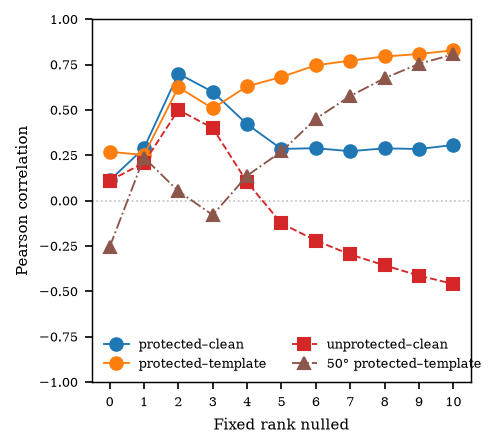

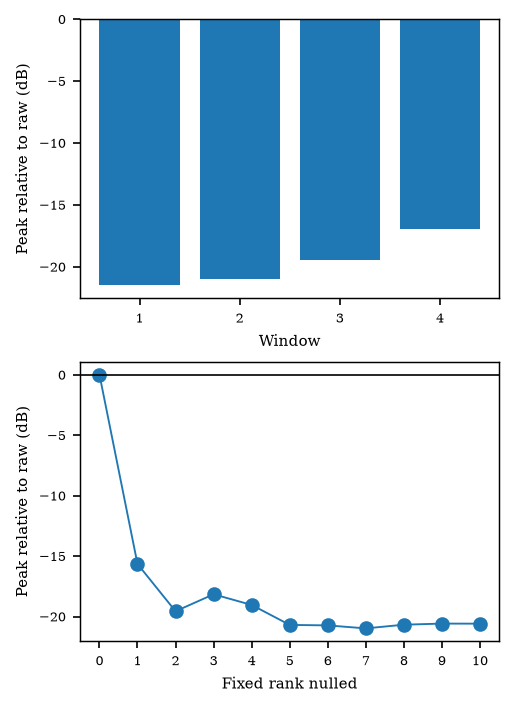

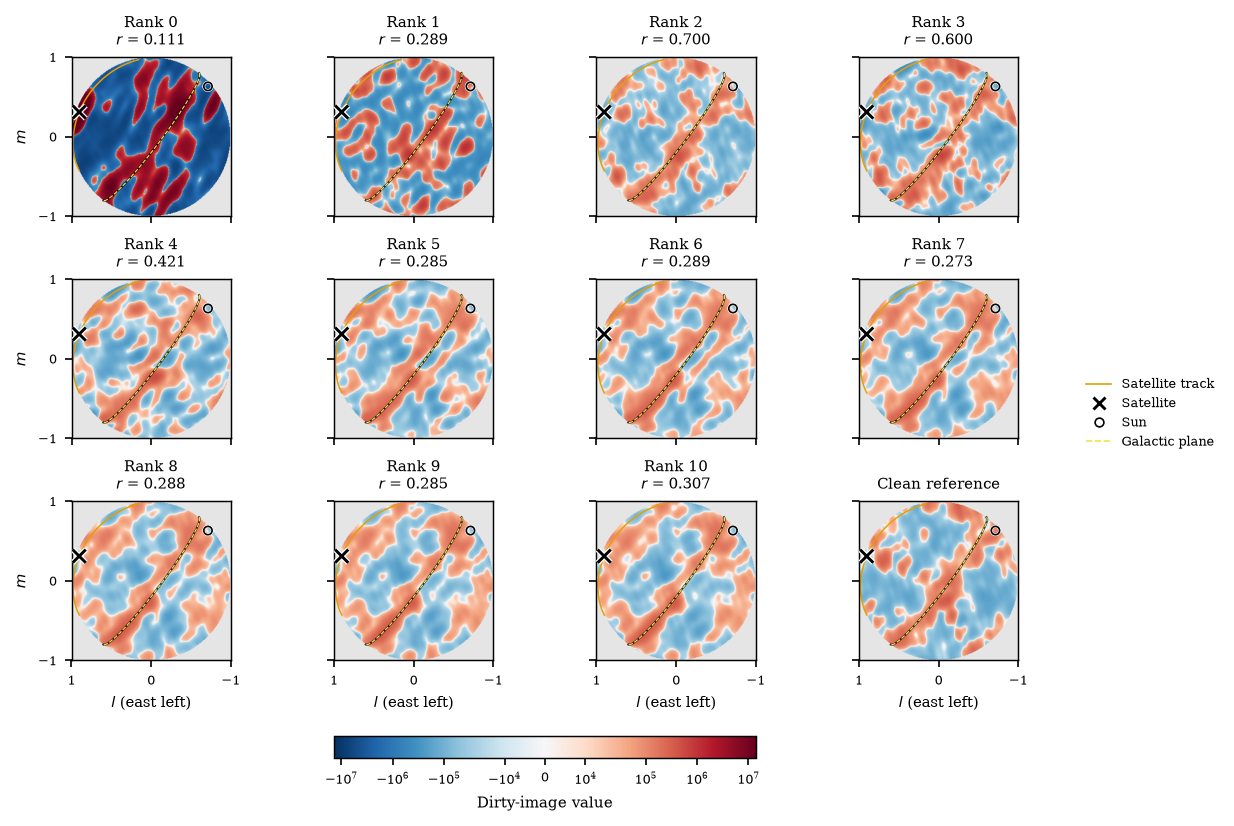

Saved:
haslam_fixed7_window2_rank_sweep_120s.pdf
haslam_fixed7_peak_suppression_120s.png
haslam_fixed7_window2_rank_sweep_dirty_images_120s.png


In [8]:
# --- rank sweep correlation figure (paper Fig. 4)
rank_sweep_figure, rank_sweep_axis = plt.subplots(figsize=(3.31, 3.0))
for values, label in (
    (rank_sweep_correlations[:, 1], 'protected–clean'),
    (rank_sweep_correlations[:, 0], 'protected–template'),
):
    rank_sweep_axis.plot(rank_sweep, values, marker='o', label=label)
rank_sweep_axis.plot(
    rank_sweep, unprotected_rank_correlations,
    marker='s', ls='--', color='C3', label='unprotected–clean',
)
rank_sweep_axis.plot(
    rank_sweep, rotated_rank_correlations, marker='^', ls='-.', color='C5',
    label=f'{falsification_rotation_degrees:g}° protected–template',
)
rank_sweep_axis.axhline(0.0, color='0.75', ls=':', lw=0.8, zorder=0)
rank_sweep_axis.set(
    xlabel='Fixed rank nulled', ylabel='Pearson correlation',
    xticks=rank_sweep, ylim=(-1, 1),
)
rank_sweep_axis.legend(frameon=False, ncol=2)
rank_sweep_figure.tight_layout()
rank_sweep_figure_path = output_root / (
    f'haslam_fixed7_window{rank_window + 1}_rank_sweep_120s.pdf'
)
save_figure(rank_sweep_figure, rank_sweep_figure_path, bbox_inches='tight', pad_inches=0.05, dpi=300,
)
plt.show()

# --- peak suppression figure
suppression_figure, suppression_axes = plt.subplots(
    2, 1, figsize=(3.31, 4.6), constrained_layout=True,
)
suppression_axes[0].bar(np.arange(1, nwindow + 1), window_peak_suppression_db)
suppression_axes[0].set(
    xlabel='Window', ylabel='Peak relative to raw (dB)',
    xticks=np.arange(1, nwindow + 1),
)
suppression_axes[1].plot(rank_sweep, rank_peak_suppression_db, marker='o')
suppression_axes[1].set(
    xlabel='Fixed rank nulled', ylabel='Peak relative to raw (dB)',
    xticks=rank_sweep,
)
for axis in suppression_axes:
    axis.axhline(0, color='black', lw=0.8)
suppression_figure_path = output_root / 'haslam_fixed7_peak_suppression_120s.png'
save_figure(suppression_figure, suppression_figure_path, bbox_inches='tight', pad_inches=0.05, dpi=300,
)
plt.show()

# --- per-rank restored image grid
rank_image_figure, rank_image_axes = plt.subplots(
    3, 4, figsize=(7.1, 5.4), sharex=True, sharey=True, constrained_layout=True,
)
rank_display_images = np.concatenate(
    (rank_sweep_dirty_images, rank_clean_image[None])
)
rank_image_norm = sym_log_norm(rank_display_images)
rank_plane = snapshot_galactic_plane_lm[rank_window]
for index, axis in enumerate(rank_image_axes.flat):
    shown_rank_image = draw_lm_panel(
        axis, rank_display_images[index], rank_image_norm, window=rank_window,
    )
    if index < rank_sweep.size:
        axis.set_title(
            f'Rank {rank_sweep[index]}\n'
            f'$r$ = {rank_sweep_correlations[index, 1]:.3f}'
        )
    else:
        axis.set_title('Clean reference')
for axis in rank_image_axes[-1]:
    axis.set_xlabel('$l$ (east left)')
for axis in rank_image_axes[:, 0]:
    axis.set_ylabel('$m$')
rank_image_figure.colorbar(
    shown_rank_image, ax=rank_image_axes.ravel().tolist(),
    orientation='horizontal', fraction=0.035, pad=0.04,
    label='Dirty-image value',
)
rank_image_figure.legend(
    legend_handles, LEGEND_LABELS, loc='center left',
    bbox_to_anchor=(1.005, 0.5), frameon=False,
)
rank_image_figure_path = output_root / (
    f'haslam_fixed7_window{rank_window + 1}_rank_sweep_dirty_images_120s.png'
)
save_figure(rank_image_figure, rank_image_figure_path, bbox_inches='tight', pad_inches=0.05, dpi=300,
)
plt.show()
print('Saved:', rank_sweep_figure_path, suppression_figure_path,
      rank_image_figure_path, sep='\n')

## Does Sun protection alone recover the Sun? (no shrinking)

The rank sweep cannot separate the two Sun operations, because both are on in
every branch. Here the shrink is off on both sides and Haslam is absent
entirely, so subspace protection is the only thing that varies:

| Branch | Haslam | Sun protected | Sun shrink |
|---|---|---|---|
| no protection | no | no | **no** |
| Sun protected | no | **yes** | **no** |

Both are compared against the **raw** clean channel — no shrinking there either,
so no Sun-related processing appears anywhere in the comparison. Ranks 0–4,
where the effect of protecting a single direction is largest.

Expected: the protected curve holds up as rank grows while the unprotected one
falls away, because the Sun is being nulled in the latter and preserved in the
former. Rank 0 is an internal control — nulling nothing means protection cannot
matter, and the two branches are asserted equal to roundoff.

2026-09-03 19:30:55.999 | INFO     | lambda_rfi_mitigation.protected_pipeline:_selection_to_hdf5:107 - returning 6782 time steps...


Processed Sun-isolation rank 0


Processed Sun-isolation rank 1


Processed Sun-isolation rank 2


Processed Sun-isolation rank 3


Processed Sun-isolation rank 4
rank-0 control: branches agree to 3.4e-16 relative


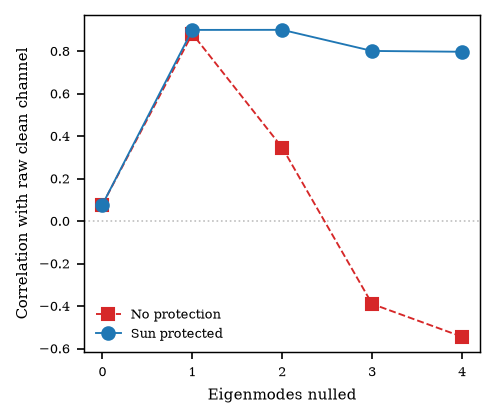

 nulled_rank  no_protection_vs_raw_clean  sun_protected_vs_raw_clean   difference
           0                    0.077726                    0.077726 2.775558e-17
           1                    0.881949                    0.900001 1.805170e-02
           2                    0.345981                    0.900344 5.543631e-01
           3                   -0.389942                    0.801034 1.190976e+00
           4                   -0.544338                    0.797156 1.341495e+00
Saved: haslam_fixed7_window2_sun_protection_isolation_120s.csv haslam_fixed7_window2_sun_protection_isolation_120s.png


In [9]:
isolation_window = rank_window          # window 2, as for the rank sweep
isolation_ranks = np.arange(5)          # 0-4
isolation_selection = slice(
    int(starts[isolation_window]), int(stops[isolation_window])
)
isolation_times = observation.time[isolation_selection]
isolation_target, isolation_valid = load_window(
    isolation_selection, config.target_channel
)
isolation_directions = sun_steering(isolation_times, target_frequency)

# Reference: the clean channel with NO shrinking (unlike images[IMAGE_CLEAN],
# which has the Sun shrunk). Straight average of the raw clean visibilities.
isolation_clean_cube, isolation_clean_valid = load_window(
    isolation_selection, clean_channel
)
isolation_clean_raw_image = image_of(
    np.mean(isolation_clean_cube[isolation_clean_valid], axis=0),
    clean_frequency,
)

isolation_unprotected = np.empty(isolation_ranks.size)
isolation_protected = np.empty(isolation_ranks.size)
isolation_images = np.empty(
    (2, isolation_ranks.size, snapshot_pixels, snapshot_pixels)
)

for index, rank in enumerate(isolation_ranks):
    for branch, protect in enumerate((False, True)):
        result = null_and_restore(
            isolation_target, isolation_directions, isolation_valid, rank,
            model=None,             # no Haslam anywhere in this experiment
            protect_sun=protect,    # the only thing that differs
            shrink_sun=False,       # no shrinking on either branch
            reduce='mean',
        )
        image = image_of(result['covariance'])
        isolation_images[branch, index] = image
        correlation = image_corr(image, isolation_clean_raw_image)
        if branch:
            isolation_protected[index] = correlation
        else:
            isolation_unprotected[index] = correlation
    print(f'Processed Sun-isolation rank {rank}')

# Internal control: at rank 0 nothing is nulled, so protecting a direction
# cannot change the answer. The two branches agree to float64 roundoff rather
# than exactly, because the nulling routine still whitens and eigendecomposes
# at rank 0; the residual is ~1e-15 relative.
_rank0_difference = np.nanmax(np.abs(
    isolation_images[0, 0] - isolation_images[1, 0]
))
_rank0_scale = np.nanmax(np.abs(isolation_images[0, 0]))
assert _rank0_difference <= 1e-12 * _rank0_scale, (
    f'rank-0 control failed: {_rank0_difference:.3e} vs scale {_rank0_scale:.3e}'
)
assert np.isclose(
    isolation_unprotected[0], isolation_protected[0], rtol=1e-10, atol=0
)
print(f'rank-0 control: branches agree to {_rank0_difference / _rank0_scale:.1e} relative')

isolation_table = pd.DataFrame({
    'nulled_rank': isolation_ranks,
    'no_protection_vs_raw_clean': isolation_unprotected,
    'sun_protected_vs_raw_clean': isolation_protected,
    'difference': isolation_protected - isolation_unprotected,
})
isolation_path = output_root / (
    f'haslam_fixed7_window{isolation_window + 1}_sun_protection_isolation_120s.csv'
)
isolation_table.to_csv(isolation_path, index=False)

isolation_figure, isolation_axis = plt.subplots(figsize=(3.31, 2.8))
isolation_axis.plot(
    isolation_ranks, isolation_unprotected, marker='s', ls='--', color='C3',
    label='No protection',
)
isolation_axis.plot(
    isolation_ranks, isolation_protected, marker='o', ls='-', color='C0',
    label='Sun protected',
)
isolation_axis.axhline(0.0, color='0.75', ls=':', lw=0.8, zorder=0)
isolation_axis.set(
    xlabel='Eigenmodes nulled', ylabel='Correlation with raw clean channel',
    xticks=isolation_ranks,
)
isolation_axis.legend(frameon=False)
isolation_figure.tight_layout()
isolation_figure_path = output_root / (
    f'haslam_fixed7_window{isolation_window + 1}_sun_protection_isolation_120s.png'
)
save_figure(isolation_figure, isolation_figure_path, bbox_inches='tight', pad_inches=0.05, dpi=300,
)
plt.show()
print(isolation_table.to_string(index=False))
print('Saved:', isolation_path, isolation_figure_path)

## Three-stage diagnostic — paper Fig. 1

One window, rank 2, the pipeline stopped at each stage:

1. **Raw target** — satellite plus Sun plus Galactic emission;
2. **Post-null, pre-shrink** — two eigenmodes gone, so the satellite is gone,
   but the Sun is still there: direct evidence that the Gram–Schmidt protection
   held it out of the nulled subspace;
3. **Restored** — after the Sun shrink and the exact Haslam add-back.

Panel 2 is the point of the figure: without protection, the Sun is one of the
brightest modes and would have been nulled along with the satellite.

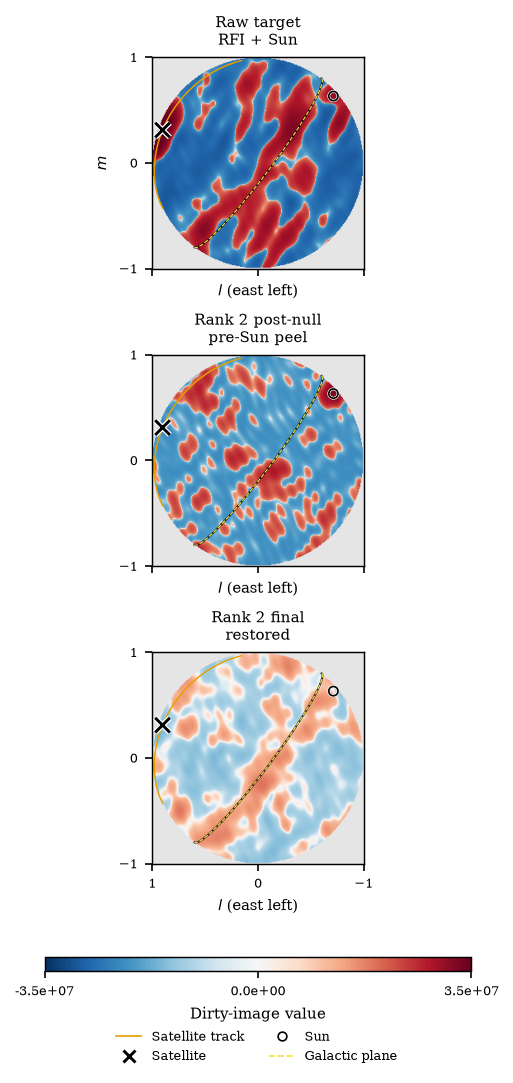

Saved: haslam_fixed7_window2_rank2_sun_protection_120s.png


In [10]:
diagnostic_window = rank_window
sun_diagnostic_images = np.stack((
    images[IMAGE_RAW, diagnostic_window],
    rank2_prepeel_image,
    rank_sweep_dirty_images[2],
))
sun_diagnostic_norm = sym_log_norm(sun_diagnostic_images)
sun_diagnostic_figure, sun_diagnostic_axes = plt.subplots(
    3, 1, figsize=(3.31, 6.8), sharex=True, sharey=True, constrained_layout=True,
)
for axis, image, title in zip(sun_diagnostic_axes, sun_diagnostic_images, (
    'Raw target\nRFI + Sun',
    'Rank 2 post-null\npre-Sun peel',
    'Rank 2 final\nrestored',
)):
    shown_sun_diagnostic = draw_lm_panel(
        axis, image, sun_diagnostic_norm, window=diagnostic_window,
        marker_scale=16 / 13,
    )
    axis.set(title=title, xlabel='$l$ (east left)')
sun_diagnostic_axes[0].set_ylabel('$m$')
sun_diagnostic_colorbar = sun_diagnostic_figure.colorbar(
    shown_sun_diagnostic, ax=sun_diagnostic_axes.tolist(),
    orientation='horizontal', fraction=0.05, pad=0.05, aspect=30,
    label='Dirty-image value',
)
_limit = float(sun_diagnostic_norm.vmax)
sun_diagnostic_colorbar.set_ticks([-_limit, 0.0, _limit])
sun_diagnostic_colorbar.ax.xaxis.set_major_formatter(
    mpl.ticker.FuncFormatter(lambda value, _: f'{value:.1e}')
)
sun_diagnostic_colorbar.ax.minorticks_off()
sun_diagnostic_figure.legend(
    legend_handles, LEGEND_LABELS, loc='lower center',
    bbox_to_anchor=(0.5, -0.045), ncol=2, frameon=False,
)
sun_diagnostic_path = output_root / (
    f'haslam_fixed7_window{diagnostic_window + 1}_rank2_sun_protection_120s.png'
)
save_figure(sun_diagnostic_figure, sun_diagnostic_path, bbox_inches='tight', pad_inches=0.05, dpi=300,
)
plt.show()
print('Saved:', sun_diagnostic_path)

## Rank-2 four-window comparison — paper Fig. 2 (`fig:rfi-comparison`)

The headline configuration, and the operating point the paper reports: two
nulled eigenmodes per 17.7 ms integration. Same calls as the fixed-7 block,
with `rank=2`. The unprotected branch here is *Haslam*-unprotected only: the Sun
stays protected and shrunk on both sides, so the comparison isolates the Haslam
mechanism rather than mixing in the Sun operations. Columns read model → clean
channel → raw → what nulling without the Haslam protection does → what protected
nulling does.

2026-09-03 19:31:09.489 | INFO     | lambda_rfi_mitigation.protected_pipeline:_selection_to_hdf5:107 - returning 6782 time steps...


Processed fixed-2 window 1


2026-09-03 19:31:23.285 | INFO     | lambda_rfi_mitigation.protected_pipeline:_selection_to_hdf5:107 - returning 6782 time steps...


Processed fixed-2 window 2


2026-09-03 19:31:35.238 | INFO     | lambda_rfi_mitigation.protected_pipeline:_selection_to_hdf5:107 - returning 6782 time steps...


Processed fixed-2 window 3


Processed fixed-2 window 4


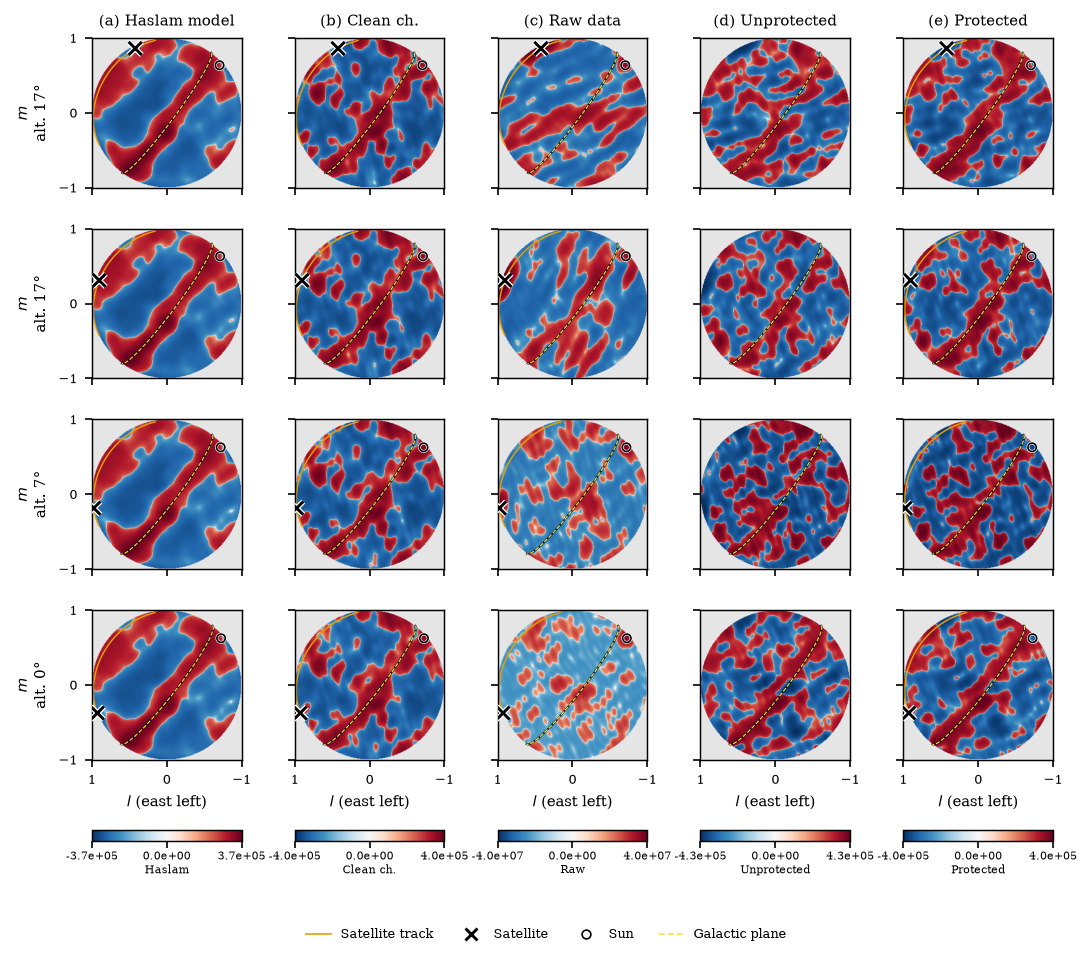

Saved: haslam_fixed2_dirty_protection_120s_sun_shrunk.pdf


In [11]:
comparison_rank = 2
rank2_protected_covariance = np.empty_like(raw_covariance)
rank2_unprotected_covariance = np.empty_like(raw_covariance)
for window, (start, stop) in enumerate(zip(starts, stops)):
    selection = slice(int(start), int(stop))
    times = observation.time[selection]
    target, target_valid = load_window(selection, config.target_channel)
    directions = sun_steering(times, target_frequency)

    protected = null_and_restore(
        target, directions, target_valid, comparison_rank,
        model=physical_haslam_model(times),
        protect_sun=True, shrink_sun=True, reduce='running',
    )
    unprotected = null_and_restore(
        target, directions, target_valid, comparison_rank,
        model=None, protect_sun=True, shrink_sun=True, reduce='mean',
    )
    rank2_protected_covariance[window] = protected['covariance']
    rank2_unprotected_covariance[window] = unprotected['covariance']
    print('Processed fixed-2 window', window + 1)

rank2_images = images.copy()
for window in range(nwindow):
    rank2_images[IMAGE_UNPROTECTED, window] = image_of(
        rank2_unprotected_covariance[window]
    )
    rank2_images[IMAGE_PROTECTED, window] = image_of(
        rank2_protected_covariance[window]
    )
rank2_norms = (
    sym_log_norm(rank2_images[0]), sym_log_norm(rank2_images[1]),
    sym_log_norm(rank2_images[[2, 4]]), sym_log_norm(rank2_images[3]),
    sym_log_norm(rank2_images[[2, 4]]),
)
rank2_figure_path = output_root / 'haslam_fixed2_dirty_protection_120s_sun_shrunk.pdf'
five_column_comparison(
    rank2_images, rank2_norms, rank2_figure_path, dpi=300,
)
plt.show()
print('Saved:', rank2_figure_path)

## Every channel against the clean channel — one window

Raw 120 s averages of each of the eight channels in the capture, imaged and
correlated against the clean channel (channel 0) over the visible hemisphere.
No nulling and no Haslam peel; the Sun is shrunk to noise in every channel,
as in the clean-channel column of the main figures. This is the unmitigated
inter-channel agreement, so it says which channels the satellite actually
touches and what the RFI-free channels agree to.


In [12]:
# --- image-domain correlation of every channel against the clean channel ---
# Plotted in the combined two-panel figure in the next cell.
channel_scan_window = rank_window     # window 2, as for the rank sweep
channel_scan_selection = slice(
    int(starts[channel_scan_window]), int(stops[channel_scan_window])
)
channel_scan_times = observation.time[channel_scan_selection]
channel_scan_images = []
for channel in range(observation.frequencies.size):
    frequency = float(observation.frequencies[channel])
    cube, valid = load_window(channel_scan_selection, channel)
    # Unmitigated but Sun-shrunk, matching the clean-channel column of the
    # main figures: no nulling, no Haslam, Sun response taken down to noise.
    peeled, _ = shrink_directional_eigenmodes_to_noise(
        np.mean(cube[valid], axis=0),
        sun_steering(channel_scan_times[valid], frequency),
        observation.snapshots_per_integration * np.count_nonzero(valid),
    )
    channel_scan_images.append(image_of(peeled, frequency))

channel_scan_table = pd.DataFrame({
    'channel': np.arange(len(channel_scan_images)),
    'frequency_MHz': np.asarray(observation.frequencies) / 1e6,
    'correlation_with_clean': [
        image_corr(image, channel_scan_images[clean_channel])
        for image in channel_scan_images
    ],
    'peak_in_disk': [peak_in_disk(image) for image in channel_scan_images],
})
channel_scan_path = output_root / (
    f'channel_vs_clean_correlation_window{channel_scan_window + 1}_120s.csv'
)
channel_scan_table.to_csv(channel_scan_path, index=False)

# Expected target-channel correlation: linear trend in frequency, fitted on the
# RFI-free channels only, extrapolated to the target.
target_frequency_mhz = float(
    channel_scan_table['frequency_MHz'][config.target_channel]
)
_frequency = channel_scan_table['frequency_MHz']
_other = channel_scan_table['channel'] != config.target_channel
_trend = np.polyfit(
    _frequency[_other], channel_scan_table['correlation_with_clean'][_other], 1,
)
expected_target_correlation = float(np.polyval(_trend, target_frequency_mhz))
actual_target_correlation = float(
    channel_scan_table['correlation_with_clean'][config.target_channel]
)

# Rank-2 mitigation result at the target frequency, plotted alongside the scan.
# Both branches keep the Sun protected and shrunk, as in the rank sweep, so
# only the Haslam protection differs between them.
assert channel_scan_window == rank_window
mitigated_correlations = {
    'Unprotected (rank 2)': float(unprotected_rank_correlations[2]),
    'Protected (rank 2)': float(rank_sweep_correlations[2, 1]),
}

print('Saved:', channel_scan_path)
for label, value in mitigated_correlations.items():
    print(f'{label}: {value:.3f}')
print(
    f'Target channel {config.target_channel} ({target_frequency_mhz:.2f} MHz): expected '
    f'{expected_target_correlation:.3f} from trend, measured '
    f'{actual_target_correlation:.3f}'
)
channel_scan_table

2026-09-03 19:31:52.099 | INFO     | lambda_rfi_mitigation.protected_pipeline:_selection_to_hdf5:107 - returning 6782 time steps...


2026-09-03 19:32:03.121 | INFO     | lambda_rfi_mitigation.protected_pipeline:_selection_to_hdf5:107 - returning 6782 time steps...


2026-09-03 19:32:14.176 | INFO     | lambda_rfi_mitigation.protected_pipeline:_selection_to_hdf5:107 - returning 6782 time steps...


2026-09-03 19:32:25.195 | INFO     | lambda_rfi_mitigation.protected_pipeline:_selection_to_hdf5:107 - returning 6782 time steps...


2026-09-03 19:32:36.204 | INFO     | lambda_rfi_mitigation.protected_pipeline:_selection_to_hdf5:107 - returning 6782 time steps...


2026-09-03 19:32:47.225 | INFO     | lambda_rfi_mitigation.protected_pipeline:_selection_to_hdf5:107 - returning 6782 time steps...


2026-09-03 19:32:56.661 | INFO     | lambda_rfi_mitigation.protected_pipeline:_selection_to_hdf5:107 - returning 6782 time steps...


Saved: channel_vs_clean_correlation_window2_120s.csv
Unprotected (rank 2): 0.500
Protected (rank 2): 0.700
Target channel 4 (137.50 MHz): expected 0.658 from trend, measured 0.114


,channel,frequency_MHz,correlation_with_clean,peak_in_disk
0,0,134.37500,1.000000,3.730812e+05
1,1,135.15625,0.971883,3.786605e+05
2,2,135.93750,0.857306,6.684023e+05
3,3,136.71875,0.858258,3.247032e+05
4,4,137.50000,0.114006,4.256019e+07
5,5,138.28125,0.546448,6.891492e+05
6,6,139.06250,0.414402,8.330520e+05
7,7,139.84375,0.359534,1.192591e+06


## Channel scan — correlation and image flux (combined figure)

Two panels over the same eight channels of one window: (a) image-domain
correlation against the clean channel, as computed above, and (b) the min,
median and max of each channel's dirty image inside the horizon. Open markers
at the target frequency are the raw, unprotected and protected rank-2 products
for the same window. Panel (b) uses a symmetric log axis: minima are negative
and maxima span decades.


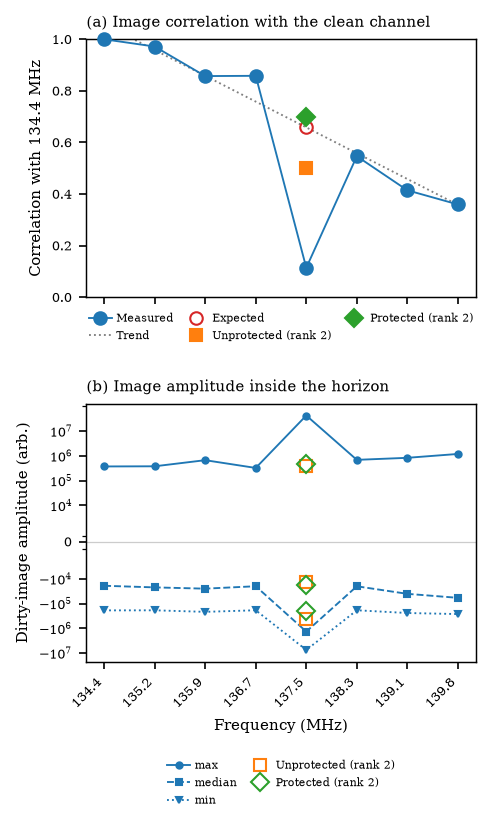

Saved: channel_flux_stats_window2_120s.csv channel_scan_correlation_flux_window2_120s.pdf


,channel,frequency_MHz,min,median,max
0,0,134.37500,-1.887340e+05,-1.911831e+04,3.730812e+05
1,1,135.15625,-1.874115e+05,-2.224278e+04,3.786605e+05
2,2,135.93750,-2.161549e+05,-2.502320e+04,6.684023e+05
3,3,136.71875,-1.866511e+05,-1.998669e+04,3.247032e+05
4,4,137.50000,-7.485954e+06,-1.354066e+06,4.256019e+07
5,5,138.28125,-1.868560e+05,-2.009212e+04,6.891492e+05
6,6,139.06250,-2.409601e+05,-4.051783e+04,8.330520e+05
7,7,139.84375,-2.656187e+05,-5.874784e+04,1.192591e+06


In [13]:
# --- per-channel image flux: min, median, max inside the horizon ---
# Same images as the correlation cell above (no recompute), plus the raw and
# rank-2 mitigated products at the target channel.
flux_stats = {
    name: [statistic(image[_disk_corr]) for image in channel_scan_images]
    for name, statistic in (
        ('min', np.nanmin), ('median', np.nanmedian), ('max', np.nanmax),
    )
}
flux_table = pd.DataFrame({
    'channel': np.arange(len(channel_scan_images)),
    'frequency_MHz': np.asarray(observation.frequencies) / 1e6,
    **flux_stats,
})
flux_path = output_root / (
    f'channel_flux_stats_window{channel_scan_window + 1}_120s.csv'
)
flux_table.to_csv(flux_path, index=False)

target_images = {
    'Unprotected (rank 2)': rank2_images[IMAGE_UNPROTECTED, channel_scan_window],
    'Protected (rank 2)': rank2_images[IMAGE_PROTECTED, channel_scan_window],
}
MITIGATION_COLOURS = ('C1', 'C2')
MITIGATION_MARKERS = ('s', 'D')

channel_figure, (correlation_axis, flux_axis) = plt.subplots(
    2, 1, figsize=(3.31, 5.6), sharex=True,
)

# --- (a) correlation with the clean channel
correlation_axis.plot(
    _frequency, channel_scan_table['correlation_with_clean'],
    marker='o', clip_on=False, zorder=3, label='Measured',
)
correlation_axis.plot(
    _frequency, np.polyval(_trend, _frequency),
    ls=':', color='0.5', lw=0.9, zorder=1, label='Trend',
)
correlation_axis.plot(
    [target_frequency_mhz], [expected_target_correlation],
    marker='o', mfc='none', color='C3', ls='none', zorder=3, label='Expected',
)
for (label, value), colour, marker in zip(
    mitigated_correlations.items(), MITIGATION_COLOURS, MITIGATION_MARKERS,
):
    correlation_axis.plot(
        [target_frequency_mhz], [value], marker=marker, color=colour,
        ls='none', zorder=4, label=label,
    )
correlation_axis.set(
    ylabel=f'Correlation with {clean_frequency / 1e6:.1f} MHz', ylim=(0, 1),
)
correlation_axis.set_title('(a) Image correlation with the clean channel', loc='left')
correlation_axis.legend(
    frameon=False, fontsize=5.5, ncol=3, loc='upper center',
    bbox_to_anchor=(0.5, -0.02), columnspacing=1.0, handletextpad=0.4,
)

# --- (b) image flux statistics
# Minima are negative and maxima span decades, so a symmetric log axis is the
# only one that shows all three statistics together.
for statistic, style, marker in (
    ('max', '-', 'o'), ('median', '--', 's'), ('min', ':', 'v'),
):
    flux_axis.plot(
        flux_table['frequency_MHz'], flux_table[statistic], ls=style,
        marker=marker, ms=3, color='C0', zorder=3,
        label=statistic,
    )
for (label, image), colour, marker in zip(
    target_images.items(), MITIGATION_COLOURS, MITIGATION_MARKERS,
):
    disk = image[_disk_corr]
    flux_axis.plot(
        [target_frequency_mhz] * 3,
        [np.nanmax(disk), np.nanmedian(disk), np.nanmin(disk)],
        marker=marker, mfc='none', color=colour, ls='none', zorder=4, label=label,
    )
_flux_scale = float(np.nanmax(np.abs(flux_table[['min', 'max']].to_numpy())))
_flux_linthresh = _flux_scale * 1e-4
flux_axis.set_yscale('symlog', linthresh=_flux_linthresh)
# Explicit decades: the default locator puts a tick inside the linear region,
# whose label collides with the 0 label.
_flux_decades = [
    10.0 ** power for power in range(
        int(np.ceil(np.log10(_flux_linthresh))),
        int(np.floor(np.log10(_flux_scale))) + 1,
    )
]
flux_axis.set_yticks([-value for value in _flux_decades[::-1]] + [0.0] + _flux_decades)
flux_axis.axhline(0.0, color='0.8', lw=0.6, zorder=0)
flux_axis.set(
    xlabel='Frequency (MHz)', ylabel='Dirty-image amplitude (arb.)',
    xticks=flux_table['frequency_MHz'],
)
flux_axis.set_xticklabels(
    [f'{value:.1f}' for value in flux_table['frequency_MHz']],
    rotation=45, ha='right',
)
flux_axis.set_title('(b) Image amplitude inside the horizon', loc='left')
flux_axis.legend(
    frameon=False, fontsize=5.5, ncol=2, loc='upper center',
    bbox_to_anchor=(0.5, -0.34), columnspacing=1.0, handletextpad=0.4,
)

channel_figure.tight_layout(h_pad=2.2)
channel_figure_path = output_root / (
    f'channel_scan_correlation_flux_window{channel_scan_window + 1}_120s.pdf'
)
save_figure(channel_figure, channel_figure_path, dpi=300)
plt.show()
print('Saved:', flux_path, channel_figure_path)
flux_table
